<a href="https://colab.research.google.com/github/fatimaezzahrabakas61-web/meteo_project/blob/main/visualisationmarketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

def setup_visuals():
    sns.set(style="whitegrid")
    plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
def plot_global_kpis(results):
    kpis = {
        "Conversion": results["conversion_rate"],
        "Retention": results["retention_rate"],
        "Subscription": results["subscription_rate"],
        "Churn": results["churn_rate"]
    }

    plt.bar(kpis.keys(), kpis.values())
    plt.title("Global Marketing KPIs")
    plt.ylabel("Rate")
    plt.show()

In [3]:
def plot_channel_performance(df_channel):
    sns.barplot(
        data=df_channel,
        x="marketing_channel",
        y="conversion_rate"
    )

    plt.title("Conversion Rate by Marketing Channel")
    plt.xticks(rotation=45)
    plt.show()

In [4]:
def plot_age_performance(df_age):
    sns.barplot(
        data=df_age,
        x="age_group",
        y="conversion_rate"
    )

    plt.title("Conversion Rate by Age Group")
    plt.show()

In [5]:
def plot_variant_performance(df_variant):
    sns.barplot(
        data=df_variant,
        x="variant",
        y="conversion_rate"
    )

    plt.title("A/B Test: Control vs Personalization")
    plt.show()

In [6]:
def plot_funnel(df):
    total = df["user_id"].nunique()
    converted = df[df["converted"] == True]["user_id"].nunique()
    subscribed = df[df["date_subscribed"].notna()]["user_id"].nunique()
    retained = df[df["is_retained"] == True]["user_id"].nunique()

    stages = ["Exposed", "Converted", "Subscribed", "Retained"]
    values = [total, converted, subscribed, retained]

    plt.plot(stages, values, marker='o')
    plt.title("Marketing Funnel")
    plt.ylabel("Users")
    plt.show()

In [7]:
def plot_conversion_over_time(df):
    df_time = df.copy()
    df_time["date_served"] = pd.to_datetime(df_time["date_served"])

    trend = (
        df_time.groupby("date_served")
        .agg(conversion_rate=("converted", "mean"))
        .reset_index()
    )

    plt.plot(trend["date_served"], trend["conversion_rate"])
    plt.title("Conversion Rate Over Time")
    plt.xticks(rotation=45)
    plt.show()

In [8]:
def plot_heatmap_channel_age(df):
    pivot = df.pivot_table(
        index="age_group",
        columns="marketing_channel",
        values="converted",
        aggfunc="mean"
    )

    sns.heatmap(pivot, annot=True, fmt=".2f")
    plt.title("Conversion Rate: Channel vs Age")
    plt.show()

In [9]:
def run_visualization_pipeline(df, results):
    setup_visuals()

    plot_global_kpis(results)
    plot_channel_performance(results["by_channel"])
    plot_age_performance(results["by_age"])
    plot_variant_performance(results["by_variant"])

    plot_funnel(df)
    plot_conversion_over_time(df)
    plot_heatmap_channel_age(df)

### Préparation des données pour `run_visualization_pipeline`

Pour exécuter correctement la fonction `run_visualization_pipeline`, nous devons préparer deux arguments : un DataFrame `df` contenant toutes les données brutes, et un dictionnaire `results` qui contiendra les indicateurs clés de performance (KPIs) et les performances segmentées par canal, âge et variante.

In [13]:
import pandas as pd

# 1. Charger le fichier CSV dans un DataFrame (df)
df = pd.read_csv('marketing_clean.csv')

# Convertir la colonne 'date_served' en datetime pour les analyses temporelles
df['date_served'] = pd.to_datetime(df['date_served'])


### Calcul des KPI et des résultats segmentés

Nous allons maintenant calculer les métriques requises pour le dictionnaire `results`.

In [14]:
# 2. Calculer les métriques pour le dictionnaire 'results'

# Global KPIs
conversion_rate = df['converted'].mean()
retention_rate = df['is_retained'].mean()
subscription_rate = df['date_subscribed'].notna().mean()

# Assumant que 'churn_rate' est l'inverse de 'retention_rate' pour la simplicité, ou nécessite une définition plus spécifique
churn_rate = 1 - retention_rate # Ceci est une hypothèse simplifiée

# Performance par canal de marketing
by_channel_df = df.groupby('marketing_channel')['converted'].mean().reset_index()
by_channel_df.rename(columns={'converted': 'conversion_rate'}, inplace=True)

# Performance par groupe d'âge
by_age_df = df.groupby('age_group')['converted'].mean().reset_index()
by_age_df.rename(columns={'converted': 'conversion_rate'}, inplace=True)

# Performance par variante (A/B test)
# Assumons qu'une colonne 'variant' existe pour l'A/B test (e.g., 'Control', 'Personalization')
# Si 'variant' n'existe pas, cette partie devra être ajustée.
if 'variant' in df.columns:
    by_variant_df = df.groupby('variant')['converted'].mean().reset_index()
    by_variant_df.rename(columns={'converted': 'conversion_rate'}, inplace=True)
else:
    # Créer un DataFrame vide ou un placeholder si la colonne 'variant' n'existe pas
    by_variant_df = pd.DataFrame({'variant': ['N/A'], 'conversion_rate': [0]})
    print("Warning: 'variant' column not found in df. Using placeholder for by_variant_df.")

# Rassembler toutes les métriques dans le dictionnaire results_dict
results_dict = {
    "conversion_rate": conversion_rate,
    "retention_rate": retention_rate,
    "subscription_rate": subscription_rate,
    "churn_rate": churn_rate,
    "by_channel": by_channel_df,
    "by_age": by_age_df,
    "by_variant": by_variant_df
}

print("Données 'df' et dictionnaire 'results_dict' préparés.")


Données 'df' et dictionnaire 'results_dict' préparés.


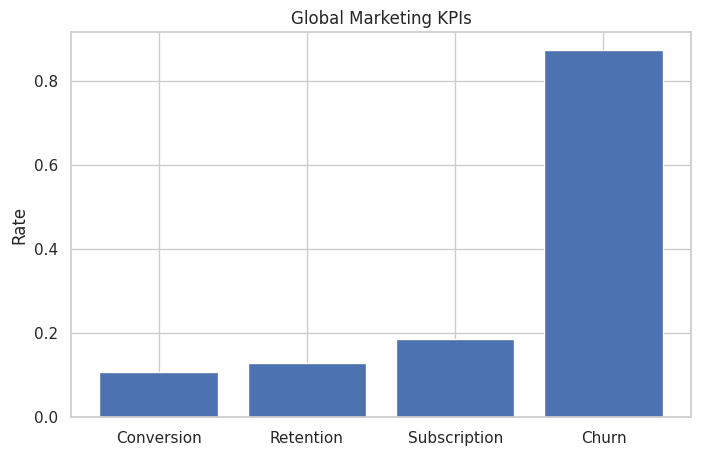

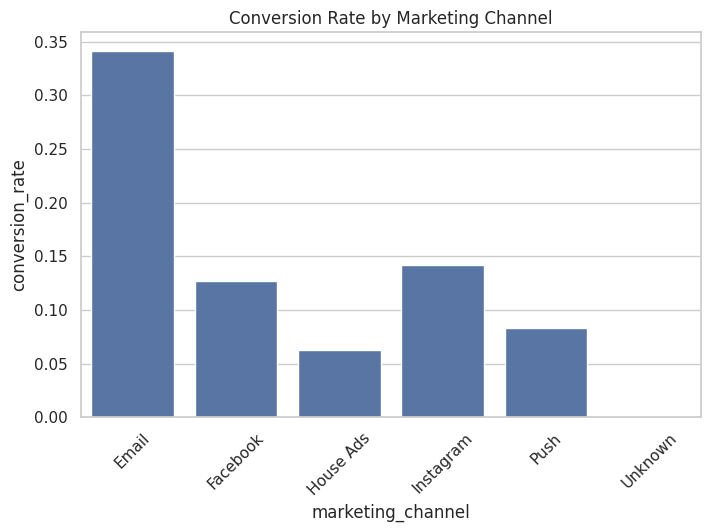

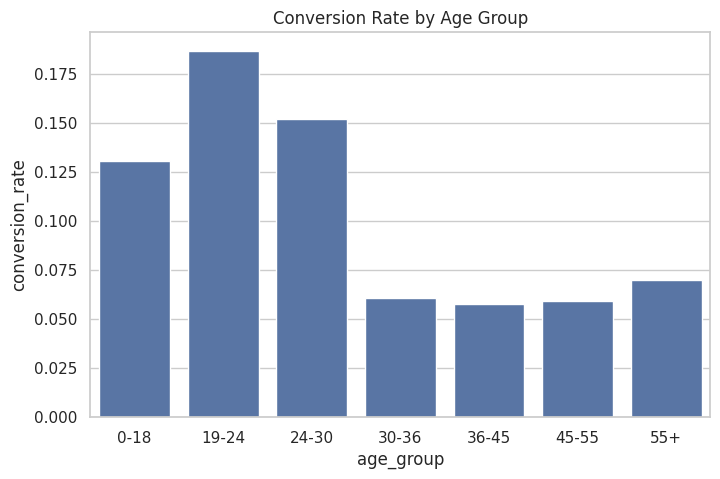

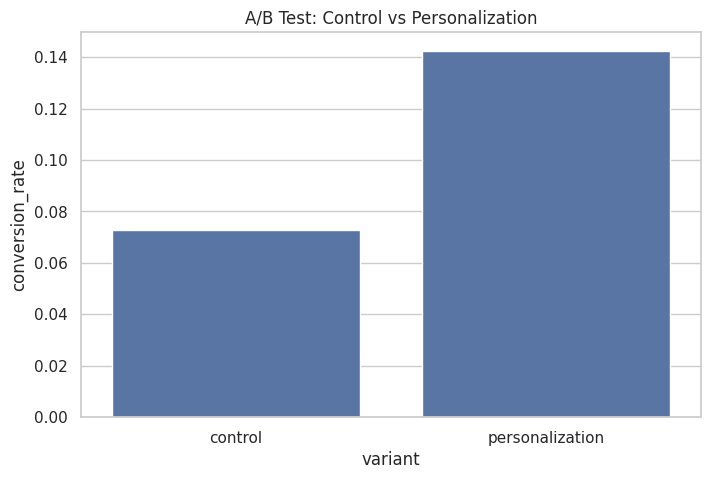

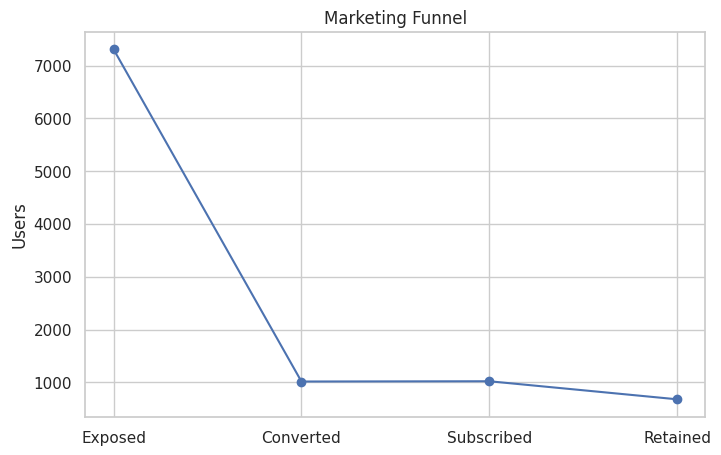

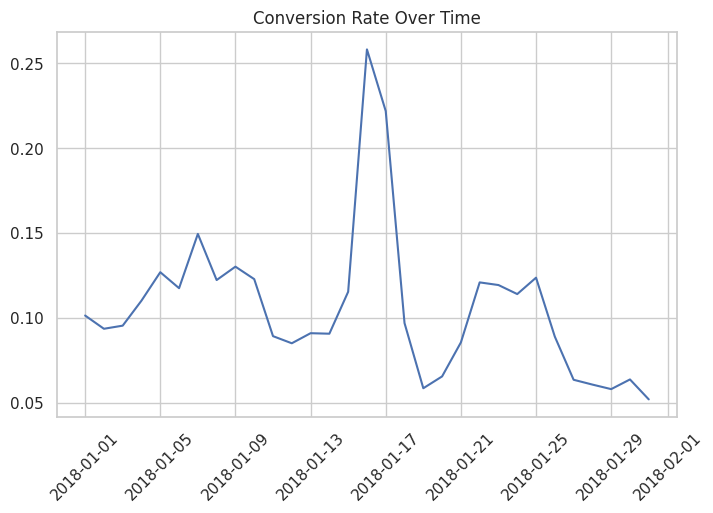

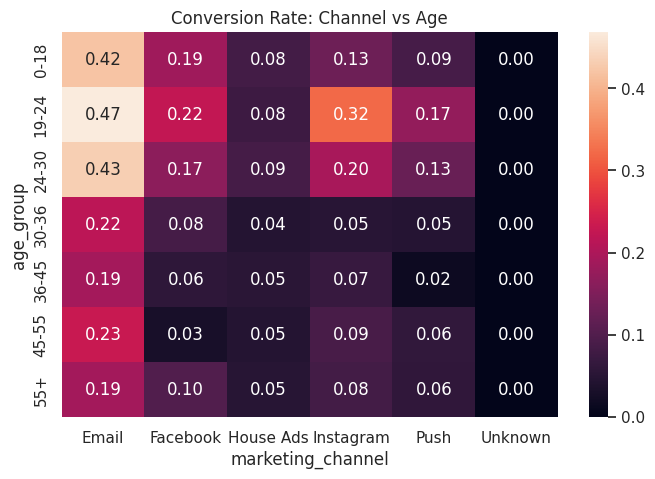

In [15]:
# 3. Exécuter le pipeline de visualisation avec le DataFrame et le dictionnaire de résultats
run_visualization_pipeline(df, results_dict)